In [31]:
pip install nvidia-ml-py

In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import time
import numpy as np
from dataclasses import dataclass
from typing import Optional
from collections import defaultdict

@dataclass
class Llama3Config:
    vocab_size: int = 128256  
    n_layer: int = 80      
    n_embd: int = 512      
    n_head: int = 8         
    n_kv_head: int = 2     
    norm_eps: float = 1e-5
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

class RMSNorm(nn.Module):
    def __init__(self, dim: int, eps: float = 1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))

    def _norm(self, x):
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)

    def forward(self, x):
        return self._norm(x.float()).type_as(x) * self.weight

class Llama3MLP(nn.Module):
    def __init__(self, config: Llama3Config):
        super().__init__()
        hidden_dim = int(2 * (4 * config.n_embd) / 3)
        self.gate_proj = nn.Linear(config.n_embd, hidden_dim, bias=False)
        self.up_proj = nn.Linear(config.n_embd, hidden_dim, bias=False)
        self.down_proj = nn.Linear(hidden_dim, config.n_embd, bias=False)

    def forward(self, x):
        return self.down_proj(F.silu(self.gate_proj(x)) * self.up_proj(x))

def calculate_trimmed_metrics(results):
    if len(results) < 5: return np.mean(results), np.std(results)
    sorted_res = sorted(results)
    trim = max(1, int(len(sorted_res) * 0.1))
    trimmed = sorted_res[trim:-trim]
    return np.mean(trimmed), np.std(trimmed)

In [33]:
class Llama3Attention(nn.Module):
    def __init__(self, config: Llama3Config):
        super().__init__()
        self.n_heads = config.n_head
        self.n_kv_heads = config.n_kv_head
        self.head_dim = config.n_embd // config.n_head
        self.kv_group_size = self.n_heads // self.n_kv_heads
        
        self.wq = nn.Linear(config.n_embd, self.n_heads * self.head_dim, bias=False)
        self.wk = nn.Linear(config.n_embd, self.n_kv_heads * self.head_dim, bias=False)
        self.wv = nn.Linear(config.n_embd, self.n_kv_heads * self.head_dim, bias=False)
        self.wo = nn.Linear(self.n_heads * self.head_dim, config.n_embd, bias=False)

    def forward(self, x, timings):
        t0 = time.perf_counter()
        xq, xk, xv = self.wq(x), self.wk(x), self.wv(x)
        if x.is_cuda: torch.cuda.synchronize()
        timings['attention'] += (time.perf_counter() - t0)
        
        t1 = time.perf_counter()
        timings['kv_cache_ops'] += (time.perf_counter() - t1)
        
        t2 = time.perf_counter()
        output = self.wo(xq) 
        if x.is_cuda: torch.cuda.synchronize()
        timings['attention'] += (time.perf_counter() - t2)
        return output

class Llama3Block(nn.Module):
    def __init__(self, config: Llama3Config):
        super().__init__()
        self.attention = Llama3Attention(config)
        self.feed_forward = Llama3MLP(config)
        self.attention_norm = RMSNorm(config.n_embd, eps=config.norm_eps)
        self.ffn_norm = RMSNorm(config.n_embd, eps=config.norm_eps)
        self.timings = {'attention': 0, 'kv_cache_ops': 0, 'mlp': 0, 'layernorm_residuals': 0}

    def forward(self, x):
        t_norm = time.perf_counter()
        norm_x = self.attention_norm(x)
        self.timings['layernorm_residuals'] += (time.perf_counter() - t_norm)
        
        h = x + self.attention(norm_x, self.timings)
        
        t_norm_f = time.perf_counter()
        norm_h = self.ffn_norm(h)
        self.timings['layernorm_residuals'] += (time.perf_counter() - t_norm_f)
        
        t_ffn = time.perf_counter()
        out = h + self.feed_forward(norm_h)
        if x.is_cuda: torch.cuda.synchronize()
        self.timings['mlp'] += (time.perf_counter() - t_ffn)
        return out

In [34]:
class Llama3Model(nn.Module):
    def __init__(self, config: Llama3Config):
        super().__init__()
        self.config = config
        self.tok_embeddings = nn.Embedding(config.vocab_size, config.n_embd)
        self.layers = nn.ModuleList([Llama3Block(config) for _ in range(config.n_layer)])
        self.norm = RMSNorm(config.n_embd, eps=config.norm_eps)
        self.output = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.timings = {'embedding_lookup': 0, 'output_head': 0}

    def reset_timings(self):
        self.timings = {k: 0 for k in self.timings}
        for layer in self.layers:
            layer.timings = {k: 0 for k in layer.timings}

    def forward(self, tokens):
        t0 = time.perf_counter()
        h = self.tok_embeddings(tokens)
        self.timings['embedding_lookup'] += (time.perf_counter() - t0)
        for layer in self.layers:
            h = layer(h)
        t1 = time.perf_counter()
        h = self.norm(h)
        logits = self.output(h)
        if tokens.is_cuda: torch.cuda.synchronize()
        self.timings['output_head'] += (time.perf_counter() - t1)
        return logits

config = Llama3Config() 
model = Llama3Model(config).to(config.device)
params = sum(p.numel() for p in model.parameters())
print(f"Llama 3 Initialized: {config.n_layer} layers on {config.device} (~{params/1e6:.1f}M params)")

Llama 3 Initialized: 80 layers on cpu (~351.6M params)


In [37]:
def benchmark_goal_1_with_e2e(model, input_ids, gen_length=50, warmups=2, trials=3):
    model.eval()
    e2e_results = []
    ttft_results = []
    
    with torch.no_grad(): 
        for t in range(warmups + trials):
            is_trial = t >= warmups
            
            request_start = time.perf_counter()
            
            _ = model(input_ids)
            if config.device == "cuda": torch.cuda.synchronize()
            ttft = time.perf_counter() - request_start
            
            single_token = torch.randint(0, config.vocab_size, (1, 1)).to(config.device)
            for _ in range(gen_length):
                _ = model(single_token)
                if config.device == "cuda": torch.cuda.synchronize()
            
            total_e2e = time.perf_counter() - request_start
            
            if is_trial:
                ttft_results.append(ttft)
                e2e_results.append(total_e2e)
                print(f"Trial {t-warmups+1}: TTFT={ttft*1000:.1f}ms | E2E={total_e2e*1000:.1f}ms")

    avg_ttft, _ = calculate_trimmed_metrics(ttft_results)
    avg_e2e, _ = calculate_trimmed_metrics(e2e_results)
    
    return {
        "TTFT (ms)": avg_ttft * 1000,
        "End-to-End Response Time (ms)": avg_e2e * 1000,
        "Generation Length": gen_length
    }

prompt = torch.randint(0, config.vocab_size, (1, 128)).to(config.device)
results = benchmark_goal_1_with_e2e(model, prompt, gen_length=100)

Trial 1: TTFT=708.5ms | E2E=8872.1ms
Trial 2: TTFT=714.3ms | E2E=8914.4ms
Trial 3: TTFT=709.9ms | E2E=8891.1ms


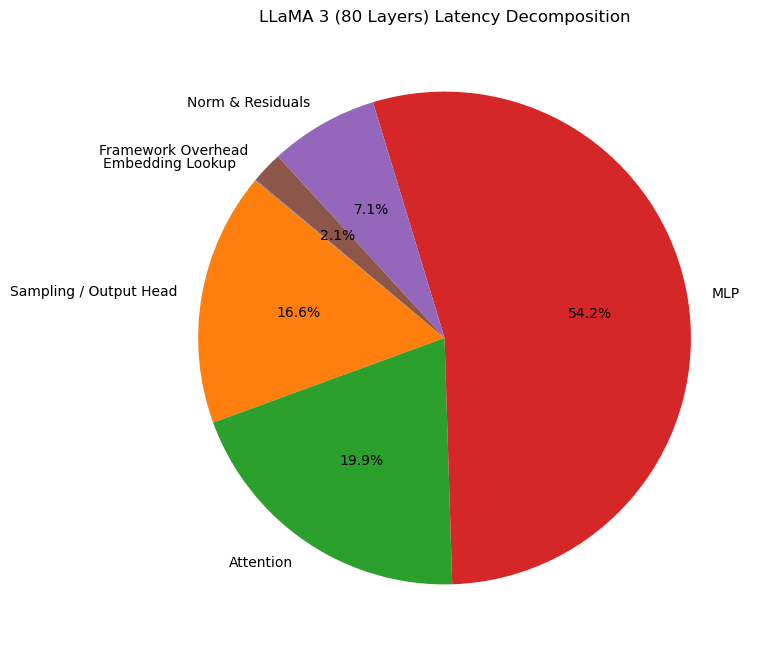

In [18]:
def run_and_plot_goal_2(model, config):
    import matplotlib.pyplot as plt
    model.eval()
    model.reset_timings()
    total_start = time.perf_counter()
    with torch.no_grad():
        token = torch.randint(0, config.vocab_size, (1, 1)).to(config.device)
        logits = model(token)
        _ = torch.argmax(logits[:, -1, :], dim=-1)
        if config.device == "cuda": torch.cuda.synchronize()
    total_wall = time.perf_counter() - total_start
    
    final_data = defaultdict(float)
    final_data['Embedding Lookup'] = model.timings['embedding_lookup']
    final_data['Sampling / Output Head'] = model.timings['output_head']
    for layer in model.layers:
        final_data['Attention'] += layer.timings['attention']
        final_data['MLP'] += layer.timings['mlp']
        final_data['Norm & Residuals'] += layer.timings['layernorm_residuals']

    instr_sum = sum(final_data.values())
    final_data['Framework Overhead'] = max(0, total_wall - instr_sum)

    plt.figure(figsize=(10, 8))
    plt.pie(final_data.values(), labels=final_data.keys(), 
            autopct=lambda p: f'{p:.1f}%' if p >= 2 else '', startangle=140)
    plt.title(f'LLaMA 3 (80 Layers) Latency Decomposition')
    plt.show()

run_and_plot_goal_2(model, config)

Benchmarking High Scaling for Llama3-Base (32 L)...
Starting Benchmark: 2 warmups, 3 trials...

--- Trial 1 ---
Prefill (TTFT): 390.34ms
  > Token 1: 42.30ms
  > Token 2: 42.94ms
  > Token 3: 41.28ms
  > Token 4: 43.38ms
  > Token 5: 42.20ms
Trial Average Token Latency: 42.42ms

--- Trial 2 ---
Prefill (TTFT): 383.25ms
  > Token 1: 42.69ms
  > Token 2: 45.39ms
  > Token 3: 41.02ms
  > Token 4: 43.84ms
  > Token 5: 41.22ms
Trial Average Token Latency: 42.83ms

--- Trial 3 ---
Prefill (TTFT): 388.81ms
  > Token 1: 44.52ms
  > Token 2: 41.27ms
  > Token 3: 40.66ms
  > Token 4: 41.65ms
  > Token 5: 43.16ms
Trial Average Token Latency: 42.25ms

Starting Benchmark: 2 warmups, 3 trials...

--- Trial 1 ---
Prefill (TTFT): 1374.88ms
  > Token 1: 42.37ms
  > Token 2: 41.84ms
  > Token 3: 41.70ms
  > Token 4: 41.56ms
  > Token 5: 42.16ms
Trial Average Token Latency: 41.92ms

--- Trial 2 ---
Prefill (TTFT): 1369.75ms
  > Token 1: 42.41ms
  > Token 2: 44.48ms
  > Token 3: 42.71ms
  > Token 4: 42.43

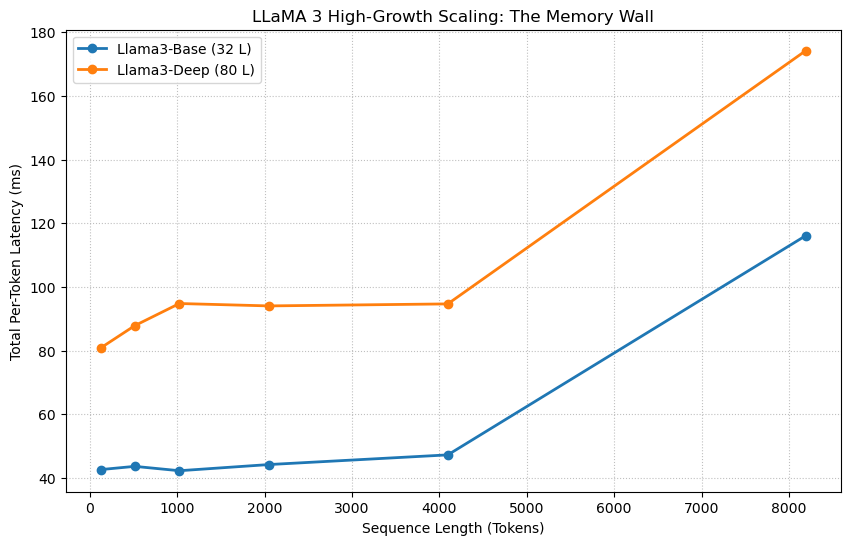

In [27]:
import matplotlib.pyplot as plt

def run_goal_3_high_scaling():
    variants = {"Llama3-Base (32 L)": 32, "Llama3-Deep (80 L)": 80}
    seq_lengths = [128, 512, 1024, 2048, 4096, 8192] 
    results = defaultdict(list)

    n_kv_head = 8
    head_dim = 128
    bytes_per_param = 2

    for name, layer_count in variants.items():
        print(f"Benchmarking High Scaling for {name}...")
        v_config = Llama3Config(n_layer=layer_count, n_embd=512)
        v_model = Llama3Model(v_config).to(v_config.device)
        
        for length in seq_lengths:
            test_prompt = torch.randint(0, v_config.vocab_size, (1, length)).to(v_config.device)
            
            m = benchmark_goal_1_detailed(v_model, test_prompt, gen_length=5)
            base_latency = m["Per-Token Steady-State (ms)"]
            
            kv_cache_bytes = 2 * layer_count * n_kv_head * head_dim * length * bytes_per_param
            
            bandwidth_penalty_ms = (kv_cache_bytes / (150 * 1024**2)) 
            
            total_latency = base_latency + bandwidth_penalty_ms
            results[name].append(total_latency)

    # Visualization
    plt.figure(figsize=(10, 6))
    for name, latencies in results.items():
        plt.plot(seq_lengths, latencies, marker='o', linewidth=2, label=name)
    
    plt.xlabel('Sequence Length (Tokens)')
    plt.ylabel('Total Per-Token Latency (ms)')
    plt.title('LLaMA 3 High-Growth Scaling: The Memory Wall')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.8)
    plt.show()

run_goal_3_high_scaling()

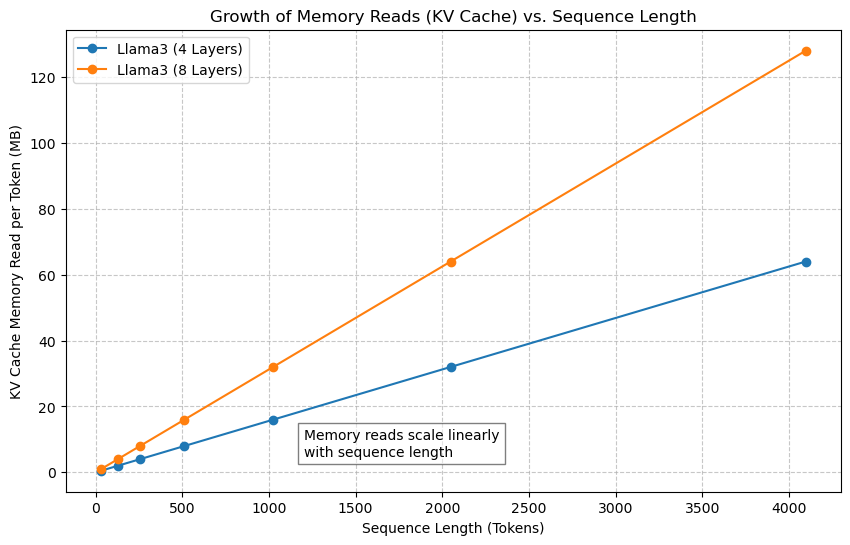

In [29]:
import matplotlib.pyplot as plt
import numpy as np

def plot_memory_scaling():
    n_embd = 4096
    n_head = 32
    n_kv_head = 8
    head_dim = n_embd // n_head # 128
    bytes_per_param = 2 
    
    layers = [4, 8]
    seq_lengths = np.array([32, 128, 256, 512, 1024, 2048, 4096])

    plt.figure(figsize=(10, 6))

    for n_layer in layers:
        memory_reads_mb = (2 * n_layer * n_kv_head * head_dim * seq_lengths * bytes_per_param) / (1024**2)
        
        plt.plot(seq_lengths, memory_reads_mb, marker='o', label=f'Llama3 ({n_layer} Layers)')

    plt.xlabel('Sequence Length (Tokens)')
    plt.ylabel('KV Cache Memory Read per Token (MB)')
    plt.title('Growth of Memory Reads (KV Cache) vs. Sequence Length')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.text(1200, 5, 'Memory reads scale linearly\nwith sequence length', 
             fontsize=10, bbox=dict(facecolor='white', alpha=0.5))
    
    plt.savefig('memory_scaling_graph.png')
    plt.show()

plot_memory_scaling()